<a href="https://colab.research.google.com/github/redrosesarecool/staz/blob/main/obiekty_kosmiczne.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# wgranie danych z pliku

from google.colab import files
uploaded = files.upload()

Saving dane-obiekty.txt to dane-obiekty.txt


In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# wczytanie danych (oddzielone przecinkami)
df = pd.read_csv("dane-obiekty.txt", header=None, names=["x", "y"], sep=",", skiprows=1)

# podgląd pierwszych danych z pliku
print(df.head())

          x          y
0  4.491979  93.009986
1  4.812834  90.870185
2  4.812834  86.875892
3  7.486631  89.443652
4  7.593583  81.740371


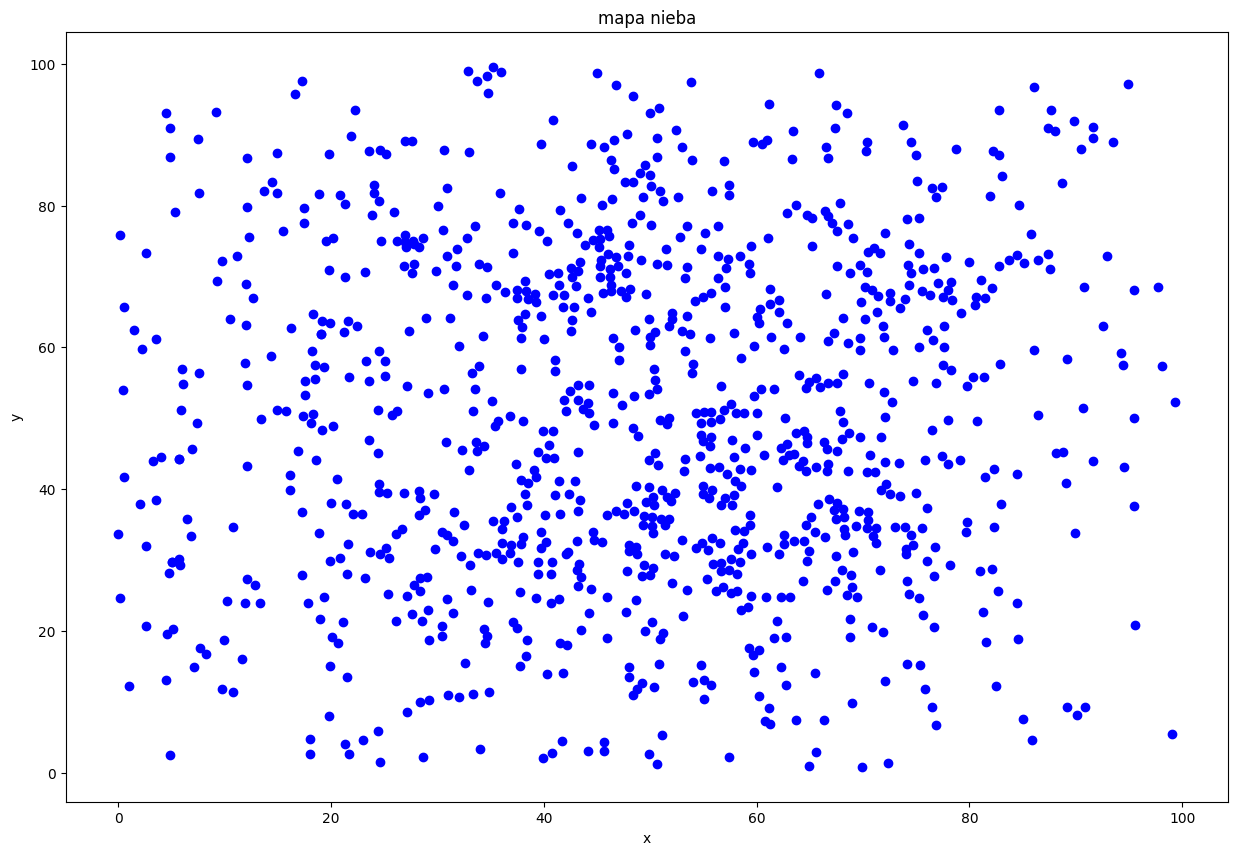

In [10]:
# rysowanie qykresu
plt.figure(figsize=(15,10))
plt.scatter(df["x"], df["y"], c="blue", marker="o")
plt.xlabel("x")
plt.ylabel("y")
plt.title("mapa nieba")
plt.grid(False)
plt.show()

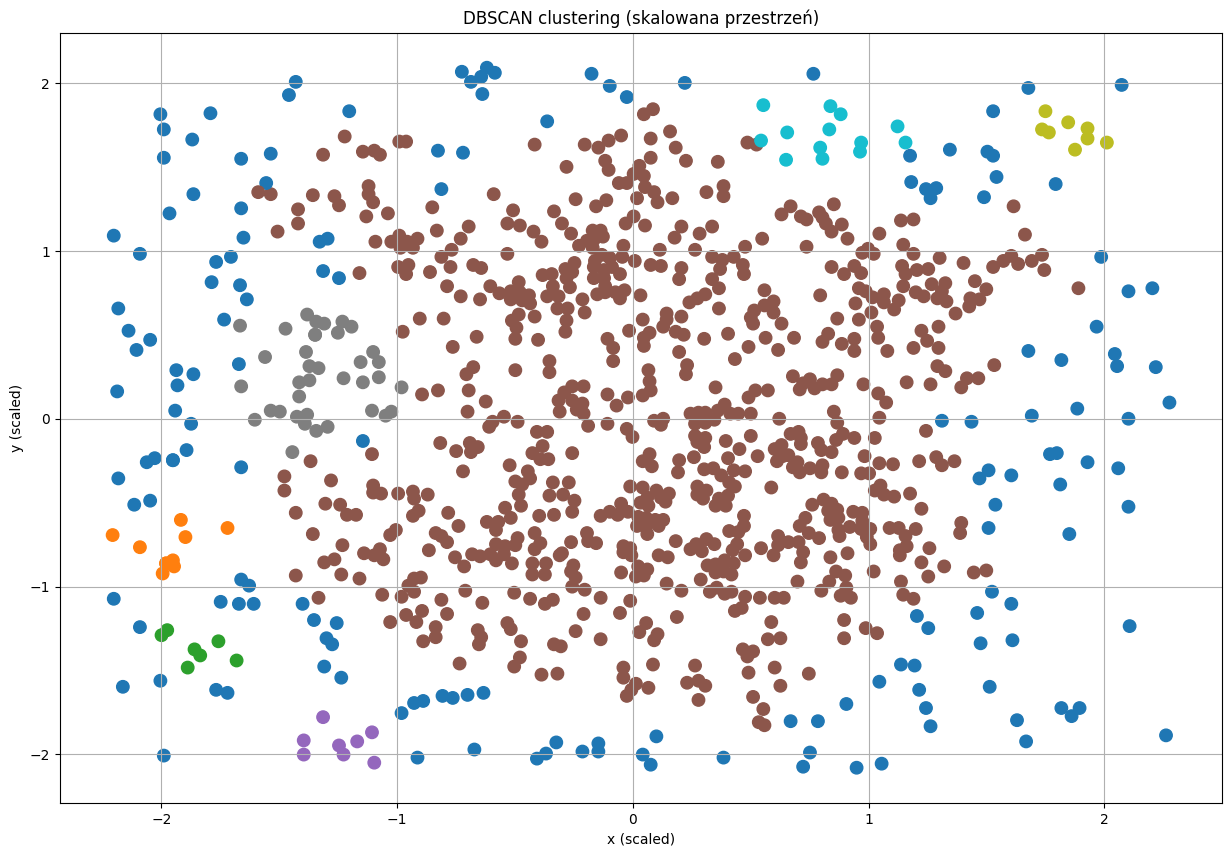

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X = df[["x", "y"]].values
X_scaled = StandardScaler().fit_transform(X)

# DBSCAN
db = DBSCAN(eps=0.2, min_samples=7).fit(X_scaled)   # eps i min_samples możesz dostroić

# etykiety klastrów
labels = db.labels_
df["cluster"] = labels

# wykres
plt.figure(figsize=(15,10))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df["cluster"], cmap="tab10", s=80)
plt.xlabel("x (scaled)")
plt.ylabel("y (scaled)")
plt.title("DBSCAN clustering (skalowana przestrzeń)")
plt.grid(True)
plt.show()


In [33]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

if n_clusters_ > 1:
    silhouette = metrics.silhouette_score(X, labels)
    print(f"Silhouette Coefficient: {silhouette:.3f}")
else:
    print("Silhouette Coefficient: cannot be computed (only 1 cluster)")

Estimated number of clusters: 7
Estimated number of noise points: 170
Silhouette Coefficient: -0.099


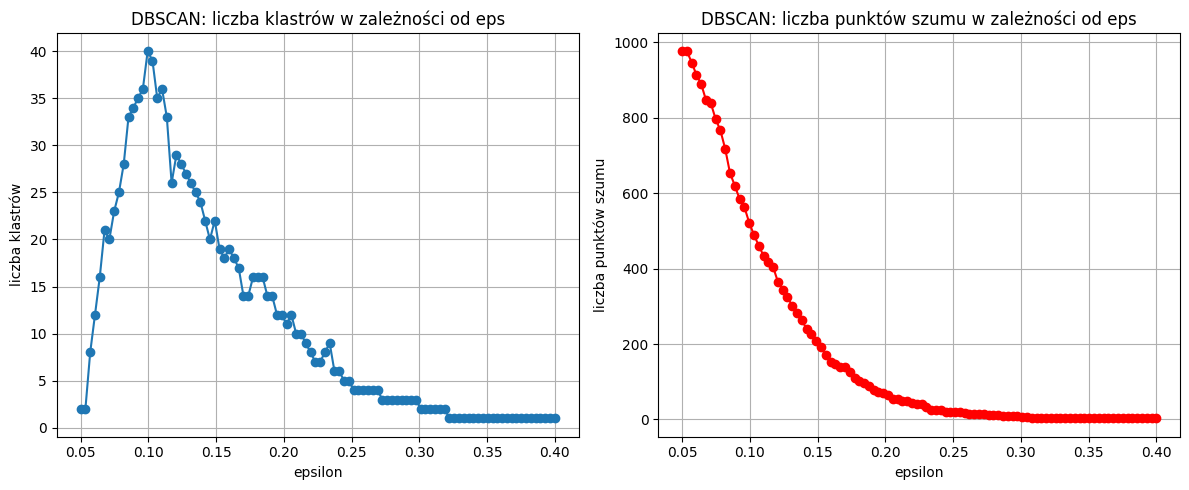

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. Wczytaj dane z pliku
df = pd.read_csv("dane-obiekty.txt", header=None, names=["x", "y"], sep=",", skiprows=1)

# 2. Skalowanie danych
X = df[["x", "y"]].values
X_scaled = StandardScaler().fit_transform(X)

# 3. Parametry do testowania
eps_values = np.linspace(0.05, 0.4, 100)  # 100 kroków od 0.05 do 0.4
min_samples = 5  # możesz zmienić

# listy do przechowywania wyników
n_clusters_list = []
n_noise_list = []

# 4. Pętla po eps
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
    labels = db.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    n_clusters_list.append(n_clusters)
    n_noise_list.append(n_noise)

# 5. Rysowanie wykresów
plt.figure(figsize=(12,5))

# liczba klastrów
plt.subplot(1,2,1)
plt.plot(eps_values, n_clusters_list, marker="o")
plt.xlabel("epsilon")
plt.ylabel("liczba klastrów")
plt.title("DBSCAN: liczba klastrów w zależności od eps")
plt.grid(True)

# liczba punktów szumu
plt.subplot(1,2,2)
plt.plot(eps_values, n_noise_list, marker="o", color="red")
plt.xlabel("epsilon")
plt.ylabel("liczba punktów szumu")
plt.title("DBSCAN: liczba punktów szumu w zależności od eps")
plt.grid(True)

plt.tight_layout()
plt.show()